# CMIP6-style SST patching: "what-if" scenario forecasts

Because `aifs-modal` decouples ingestion from inference, any IC source that follows the Brightband zarr schema can be fed to the model. This notebook shows how to construct a *modified* set of initial conditions — patching sea-surface temperatures (SSTs) with a CMIP6 end-of-century warming anomaly — by writing a custom ArrayLake repository, then running a forecast from it.

The recipe:

1. Run a baseline forecast from the Brightband IFS dataset on ArrayLake.
2. Compute a monthly SST anomaly from the [Pangeo CMIP6 cloud archive](https://pangeo-data.github.io/pangeo-cmip6-cloud/) (SSP5-8.5, 2050–2069 minus historical 1995–2014) and regrid it to the Brightband 0.25° lat/lon grid.
3. Open the Brightband source, apply the CMIP6 anomaly to skin temperature (`skt`) over ocean (where `lsm < 0.5`), and write the patched fields — together with static variables — to a new ArrayLake repository on `main`.
4. Run a second forecast using the patched ArrayLake repo as IC source and compare outputs.

AIFS does not ingest SST as a separate input — it uses **skin temperature** (`skt`) as the lower boundary, which equals SST over open ocean. So "SST patching" concretely means modifying `skt` over ocean grid points.

```{warning}
Patching only `skt` produces an *initially* inconsistent state — `2t` (2 m air temperature) over ocean is not adjusted, so the very first forecast time steps will exhibit large surface fluxes as the boundary layer responds. This is a feature of the experimental design (a "storyline" in the climate-impact-attribution sense), not a bug. To soften the initial shock you can additionally bump `2t` over ocean by the same anomaly — see *Variations* at the end of the notebook.
```

In [ ]:
import datetime as dt
import os

import arraylake
import gcsfs
import icechunk
import numpy as np
import pandas as pd
import plot_utils  # supplied alongside the other docs notebooks
import scipy.interpolate
import xarray as xr

from aifs_modal import app, run_forecast

_today_00z = dt.datetime.now(dt.UTC).replace(hour=0, minute=0, second=0, microsecond=0)
start_date = _today_00z - dt.timedelta(
    days=2
)  # safely within the Brightband ~15-day window
lead_time = 96  # hours

storage_bucket = "aifs-modal-unibe"
ifs_source_repo = "martibosch/ecmwf-ifs-hres-ics-open"  # Brightband ECMWF IFS dataset
patched_ics_repo = (
    "martibosch/aifs-modal-sst-patched"  # your own ArrayLake repo for patched ICs
)
baseline_outputs_prefix = "aifs-outputs-ifs-baseline"
patched_outputs_prefix = "aifs-outputs-ifs-warm-patch"

# CMIP6 source for the SST anomaly (Pangeo cloud archive, anonymous GCS)
# Change source_id / institution to use a different model; check available
# combinations at https://pangeo-data.github.io/pangeo-cmip6-cloud/
cmip6_source_id = "IPSL-CM6A-LR"
cmip6_institution = "IPSL"
cmip6_member_id = "r1i1p1f1"
cmip6_hist_period = slice("1995", "2014")
cmip6_ssp_period = slice("2050", "2069")

print(f"start_date: {start_date.isoformat()}")

start_date: 2026-05-02T00:00:00+00:00


## 1. Run the baseline forecast

In [ ]:
with app.run():
    run_forecast.remote(
        start_date,
        storage_bucket,
        source="ifs-arraylake",
        source_repo=ifs_source_repo,
        lead_time=lead_time,
        outputs_prefix=baseline_outputs_prefix,
    )

## 2. Compute CMIP6 SST anomaly

We load monthly mean sea-surface temperature (`tos`) from the Pangeo CMIP6 zarr archive on Google Cloud Storage and compute the SSP5-8.5 end-of-century anomaly relative to the historical baseline. The store URL is looked up from the Pangeo catalog CSV, which avoids hard-coding the `gr` vs `gn` grid-label that varies by model and variable. The anomaly is then regridded to the Brightband 0.25° lat/lon grid using `scipy.interpolate.griddata`, which handles both regular and curvilinear (e.g. IPSL ORCA1 tripolar) source grids.

```{note}
This step runs locally and requires `gcsfs`, `pandas`, and `scipy` (`pip install gcsfs pandas scipy`). Access is anonymous — no GCS credentials needed. The default model is IPSL-CM6A-LR; to use another, update `cmip6_source_id`, `cmip6_institution`, and `cmip6_member_id` in the setup cell.
```

In [ ]:
fs = gcsfs.GCSFileSystem(token="anon", access="read_only")

print("Looking up CMIP6 catalog…")
catalog = pd.read_csv(
    "https://cmip6.storage.googleapis.com/pangeo-cmip6.csv",
    dtype=str,
)


def _cmip6_zstore(experiment_id, table_id="Omon", variable_id="tos"):
    activity = (  # noqa: F841
        "CMIP" if experiment_id == "historical" else "ScenarioMIP"
    )
    hits = catalog.query(
        "activity_id == @activity"
        " and institution_id == @cmip6_institution"
        " and source_id == @cmip6_source_id"
        " and experiment_id == @experiment_id"
        " and member_id == @cmip6_member_id"
        " and table_id == @table_id"
        " and variable_id == @variable_id"
    )
    if hits.empty:
        raise FileNotFoundError(
            f"No {variable_id}/{table_id} entry for {cmip6_source_id} {experiment_id} "
            "in Pangeo catalog. Browse https://pangeo-data.github.io/pangeo-cmip6-cloud/"
        )
    zstore = hits.sort_values("zstore").iloc[-1]["zstore"]
    print(f"  {experiment_id}: {zstore}")
    return zstore


print("Loading CMIP6 SST…")
tos_hist = (
    xr.open_zarr(
        fs.get_mapper(_cmip6_zstore("historical")), consolidated=True, chunks={}
    )["tos"]
    .sel(time=cmip6_hist_period)
    .groupby("time.month")
    .mean()
)
tos_ssp585 = (
    xr.open_zarr(fs.get_mapper(_cmip6_zstore("ssp585")), consolidated=True, chunks={})[
        "tos"
    ]
    .sel(time=cmip6_ssp_period)
    .groupby("time.month")
    .mean()
)
sst_anomaly = (tos_ssp585 - tos_hist).compute()  # (month=12, ...), NaN over land

# Regrid to regular 0.25° lat/lon grid — griddata handles both regular (1D) and
# curvilinear (2D, e.g. IPSL ORCA1 tripolar) source coordinate arrays.
target_lat = np.arange(90, -90.25, -0.25)  # (721,)
target_lon = np.arange(0, 360, 0.25)  # (1440,)
target_lon_g, target_lat_g = np.meshgrid(target_lon, target_lat)

month_field = sst_anomaly.sel(month=start_date.month)

# Resolve lat/lon coordinate arrays — try CF standard names first
lat_name = next(
    (c for c in ["latitude", "lat", "nav_lat"] if c in month_field.coords), None
)
lon_name = next(
    (c for c in ["longitude", "lon", "nav_lon"] if c in month_field.coords), None
)
src_lat = month_field.coords[lat_name].values  # (y,) or (y, x)
src_lon = month_field.coords[lon_name].values  # (x,) or (y, x)
if src_lat.ndim == 1:
    src_lon, src_lat = np.meshgrid(src_lon, src_lat)

src_vals = month_field.values.ravel()
src_lon_r = src_lon.ravel()
src_lat_r = src_lat.ravel()

# Normalize lon to [0, 360] so source and target share the same range
src_lon_r = np.where(src_lon_r < 0, src_lon_r + 360, src_lon_r)

valid = ~np.isnan(src_vals)
month_anomaly_025 = scipy.interpolate.griddata(
    np.column_stack([src_lon_r[valid], src_lat_r[valid]]),
    src_vals[valid],
    (target_lon_g, target_lat_g),
    method="linear",
    fill_value=0.0,
).astype("f4")  # (721, 1440); 0 where interpolation hull has no coverage

print(
    f"Month {start_date.month} SST anomaly "
    f"({cmip6_source_id} SSP5-8.5 {cmip6_ssp_period.start}–{cmip6_ssp_period.stop} "
    f"− hist {cmip6_hist_period.start}–{cmip6_hist_period.stop}): "
    f"mean={month_anomaly_025[month_anomaly_025 > 0].mean():.2f} K, "
    f"max={month_anomaly_025.max():.2f} K"
)

Looking up CMIP6 catalog…
Loading CMIP6 SST…
  historical: gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/historical/r1i1p1f1/Omon/tos/gn/v20180803/
  ssp585: gs://cmip6/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR/ssp585/r1i1p1f1/Omon/tos/gn/v20190903/
Month 5 SST anomaly (IPSL-CM6A-LR SSP5-8.5 2050–2069 − hist 1995–2014): mean=1.62 K, max=7.57 K


## 3. Write patched ICs to ArrayLake

We read the two IC time steps needed by AIFS (`start_date − 6 h` and `start_date`) from the Brightband source, apply the CMIP6 SST anomaly to `skt` at ocean grid points (`lsm < 0.5`), and write the result — together with the static fields — to a new ArrayLake repository on `main`. This repository then serves as the IC source for the patched forecast, ingested by the same `ingest_ifs_arraylake` pipeline as the baseline.

This approach is independent of `aifs-modal` internals: it is a plain ArrayLake zarr write and can be versioned, shared, and re-run without touching any Modal state. Passing `source_static_branch="main"` in step 4 tells `ingest_ifs_arraylake` to read both dynamic and static fields from the same branch.

In [ ]:
client = arraylake.Client(token=os.environ["ARRAYLAKE_API_TOKEN"])
# alternatively, in this (local) notebook we can login interactively
# client = arraylake.Client()
# client.login()

# Open Brightband source (dynamic on main, static on add-static-vars)
source_al = client.get_repo(ifs_source_repo)
dynamic_ds = xr.open_dataset(
    source_al.readonly_session("main").store, engine="zarr", zarr_format=3, chunks={}
)
static_ds = xr.open_dataset(
    source_al.readonly_session("add-static-vars").store,
    engine="zarr",
    zarr_format=3,
    chunks={},
)

# Select the two IC dates (analysis field only: lead_time=0, kept as size-1 dim)
init_times_np = np.array(
    [
        (start_date - dt.timedelta(hours=6)).replace(tzinfo=None),
        start_date.replace(tzinfo=None),
    ],
    dtype="datetime64[ns]",
)
patched = dynamic_ds.sel(init_time=init_times_np).isel(lead_time=[0]).compute()

# Ocean mask from the Brightband static lsm (0.25° grid)
lsm_arr = static_ds["lsm"].values
while lsm_arr.ndim > 2:
    lsm_arr = lsm_arr.squeeze(axis=0)
ocean = lsm_arr < 0.5  # (721, 1440)

# Apply CMIP6 SST anomaly to skt at ocean points
skt = patched["skt"].values.copy()  # (..., 721, 1440)
skt[..., ocean] += month_anomaly_025[ocean]
patched["skt"] = xr.DataArray(
    skt, dims=patched["skt"].dims, coords=patched["skt"].coords
)
print(
    f"Patched skt: {ocean.sum()} ocean grid points, "
    f"mean anomaly = {month_anomaly_025[ocean].mean():.2f} K"
)

# Co-locate static fields (lsm, z_sfc, slor, sdor) on the same main branch so that
# ingest_ifs_arraylake can read them with source_static_branch="main"
lat_dim, lon_dim = patched["skt"].dims[-2], patched["skt"].dims[-1]
for varname in ["lsm", "z_sfc", "slor", "sdor"]:
    arr = static_ds[varname].values.astype("f4")
    while arr.ndim > 2:
        arr = arr.squeeze(axis=0)
    patched[varname] = xr.DataArray(arr, dims=[lat_dim, lon_dim])

# Write to patched ArrayLake repo (get or create if needed)
patched_al = client.get_or_create_repo(patched_ics_repo)
session = patched_al.writable_session("main")
patched.to_zarr(session.store, zarr_format=3, mode="w")
session.commit(
    f"CMIP6 {cmip6_source_id} SSP5-8.5 {cmip6_ssp_period.start}–{cmip6_ssp_period.stop}"
    f" SST anomaly applied to skt for {start_date.date()}"
)
print(f"Patched ICs written to {patched_ics_repo} (main branch)")

  2026-05-04T13:10:04.282486Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1776344638779/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:121

Patched skt: 686392 ocean grid points, mean anomaly = 1.46 K
  2026-05-04T14:16:45.668036Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1776344638779/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:121

Patched ICs written to martibosch/aifs-modal-sst-patched (main branch)


## 4. Run the patched forecast

Same `run_forecast` call as the baseline, pointing to the patched ArrayLake repo and a separate output prefix so both runs can be read side by side. `source_static_branch="main"` tells `ingest_ifs_arraylake` to read both dynamic and static fields from `main`, where we wrote everything in step 3.

In [ ]:
with app.run():
    run_forecast.remote(
        start_date,
        storage_bucket,
        source="ifs-arraylake",
        source_repo=patched_ics_repo,
        source_static_branch="main",  # static fields co-located with dynamic on main
        lead_time=lead_time,
        outputs_prefix=patched_outputs_prefix,
    )

## 5. Compare baseline vs. patched

Both forecasts are on the same 0.25° lat/lon grid, so we can subtract them directly. The expected signature of the CMIP6 anomaly patch: warmer 2 m temperatures over ocean (and propagating downstream into coastal land), shifted MSL patterns reflecting altered surface heat fluxes, and a spatially heterogeneous anomaly pattern reflecting the model's regional SST warming structure rather than a uniform shift.

In [ ]:
def open_forecast(prefix):
    storage = icechunk.tigris_storage(
        bucket=storage_bucket,
        prefix=prefix,
        region=os.getenv("AWS_REGION"),
        access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
        secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
    )
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")
    group = start_date.strftime("%Y-%m-%d/%Hz")
    return xr.open_dataset(
        session.store, group=group, engine="zarr", zarr_format=3, chunks=None
    )


ds_base = open_forecast(baseline_outputs_prefix)
ds_warm = open_forecast(patched_outputs_prefix)

diff = (ds_warm["2t"] - ds_base["2t"]).isel(init_time=0)
diff.name = "Δ 2 m temperature (warm − baseline) [K]"

  2026-05-04T14:21:34.373459Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1776344638779/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:121

  2026-05-04T14:21:35.843706Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1776344638779/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:121



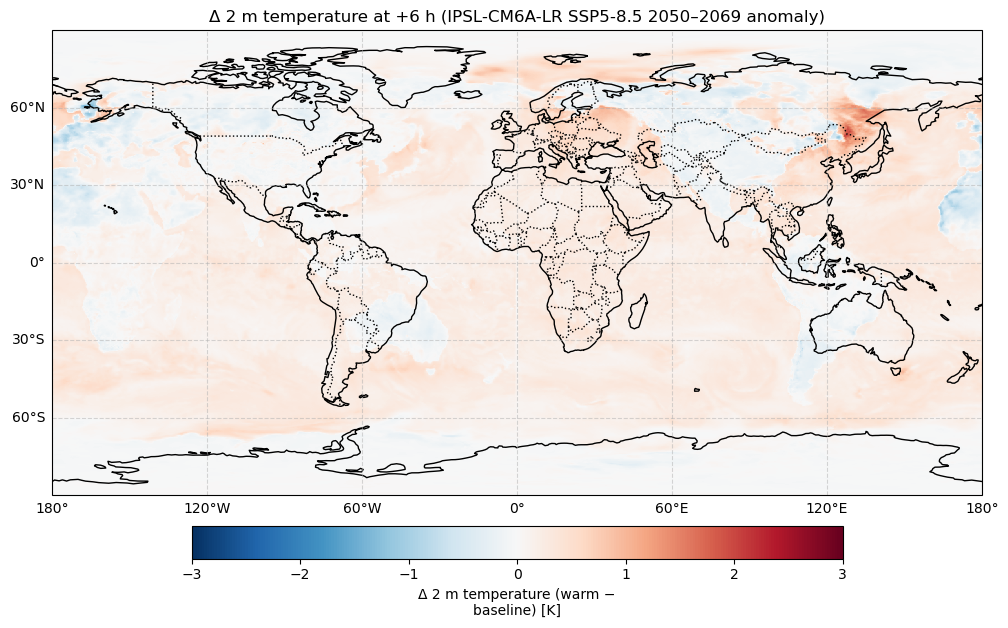

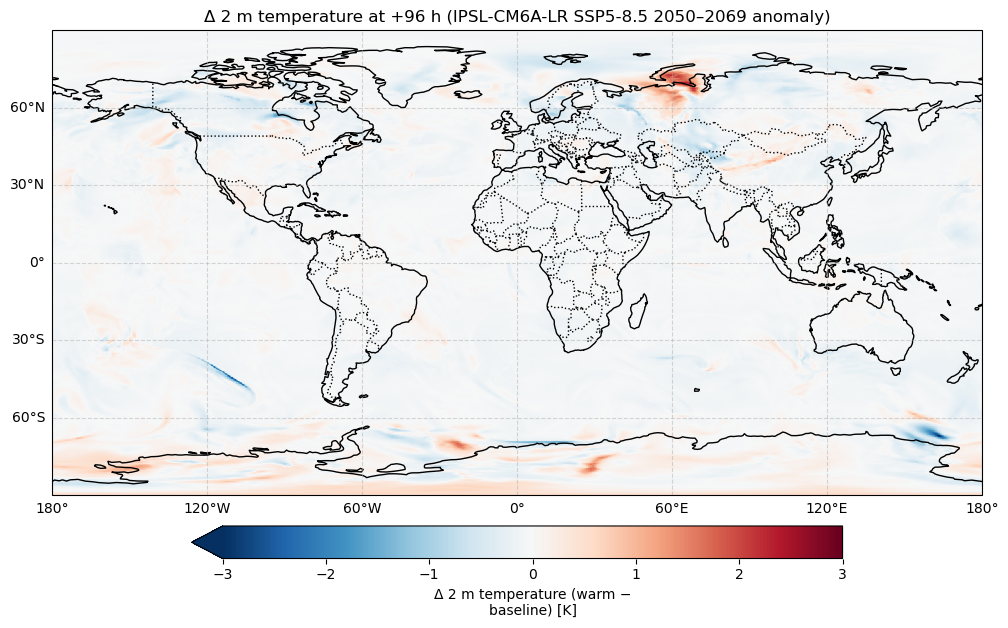

In [ ]:
anomaly_label = (
    f"{cmip6_source_id} SSP5-8.5 {cmip6_ssp_period.start}–{cmip6_ssp_period.stop} "
    "anomaly"
)
for lt_idx, label in [(0, "+6 h"), (-1, f"+{lead_time} h")]:
    _ = plot_utils.make_cartopy_plot(
        diff.isel(lead_time=lt_idx),
        cmap="RdBu_r",
        title=f"Δ 2 m temperature at {label} ({anomaly_label})",
        vmin=-3,
        vmax=3,
    )

## Variations

### Use a uniform anomaly instead of a model-specific one

For a quick sanity check or sensitivity test, replace the `scipy.interpolate.griddata` step with a constant array:

```python
# Replace the entire griddata call with:
month_anomaly_025 = np.full((721, 1440), 2.0, dtype="f4")  # uniform +2 K everywhere
```

### Patch `2t` together with `skt` to soften the initial shock

In the patch cell, add a second variable after the `skt` patching block:

```python
t2m = patched["t2m"].values.copy()
t2m[..., ocean] += month_anomaly_025[ocean]
patched["t2m"] = xr.DataArray(t2m, dims=patched["t2m"].dims, coords=patched["t2m"].coords)
```

This eliminates the day-0 air-sea temperature jump and makes the first 24 h cleaner to interpret. The downside is that you've now also imposed the warmer state on the boundary layer, blurring the question of how AIFS *responds* to a warmer ocean.

### ERA5/historical dates: patch on the Modal Volume

For dates outside the Brightband rolling window, use `source="era5-arco"` with `keep_ics=True` to retain ICs on the Modal Volume after the baseline forecast, then patch in an `@app.function` with the IC Volume mount:

```python
from datetime import timedelta
import earthkit.regrid as ekr
from aifs_modal import settings
from aifs_modal._app import app, ic_volume

@app.function(volumes={settings.IC_DIR: ic_volume})
def patch_sst_era5(start_date, anomaly_025):
    import numpy as np, zarr
    from aifs_modal import utils

    anomaly_n320 = ekr.interpolate(
        anomaly_025, {"grid": [0.25, 0.25]}, {"grid": "N320"}, method="linear"
    )
    for date in [start_date - timedelta(hours=6), start_date]:
        g = zarr.open_group(
            f"{settings.IC_DIR}/{utils.datetime_to_str(date)}", mode="r+", zarr_format=3
        )
        vnames, fields = g["variable"][:], g["fields"][:]
        skt_idx = int(np.where(vnames == "skt")[0][0])
        lsm_idx = int(np.where(vnames == "lsm")[0][0])
        ocean = fields[lsm_idx] < 0.5
        fields[skt_idx, ocean] += anomaly_n320[ocean]
        g["fields"][:] = fields
    ic_volume.commit()

with app.run():
    patch_sst_era5.remote(start_date, month_anomaly_025)
```

### Other storyline patches

The same ArrayLake-write machinery works for any Brightband variable: cooler tropical Pacific to mimic La Niña (patch `skt` in the tropics); drier soils by patching `swvl1`/`swvl2`; warmer Arctic by restricting the `ocean` mask to high latitudes. Very large or inconsistent perturbations push the model away from its training manifold — interpret results as model behaviour, not a physical prediction.

## See also

- [Initial conditions](initial-conditions.ipynb) — the four supported IC sources and how to ingest them.
- [Heatwave reforecast](heatwave-reforecast-ens.ipynb) — a reforecast example using ARCO-ERA5 ICs and AIFS-ENS.

## Cleanup

Remove all forecast data from the bucket.

In [ ]:
import storage_utils

storage_utils.delete_prefixes(
    storage_bucket,
    baseline_outputs_prefix,
    patched_outputs_prefix,
)

deleted 1552 object(s) under s3://aifs-modal-unibe/aifs-outputs-ifs-baseline
deleted 1551 object(s) under s3://aifs-modal-unibe/aifs-outputs-ifs-warm-patch
done — removed 3103 objects from s3://aifs-modal-unibe/
